# Extended analysis: what the salary–performance correlation is really measuring

Companion to `nba_salary_analysis.ipynb`. Same data, same 456 players. This notebook tests the headline result against the obvious objections:

1. How much of the correlation runs through **minutes played**?
2. Is the rookie-scale vs. veteran-max gap a finding or **arithmetic**?
3. What does a **residual-based** value measure show instead of production-per-dollar?
4. How sensitive are the results to the **production metric** and to **name-matching** losses?

Figures are saved to `figures/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

df = pd.read_csv("data/nba_salary_performance_2025_26.csv")
df["prod_per_million"] = df["productionPerGame"] / (df["salary"] / 1e6)
print(f"{len(df)} players")

456 players


## 1. Headline correlations, plus rank and log versions

In [2]:
rows = []
for m in ["pointsPerGame", "productionPerGame"]:
    r, p = stats.pearsonr(df["salary"], df[m])
    rho = stats.spearmanr(df["salary"], df[m])[0]
    rlog = stats.pearsonr(np.log(df["salary"]), df[m])[0]
    rows.append({"metric": m, "pearson_r": r, "R2": r**2, "p": p, "spearman_rho": rho, "log_salary_r": rlog})
pd.DataFrame(rows).round({"pearson_r": 3, "R2": 3, "spearman_rho": 3, "log_salary_r": 3})

,metric,pearson_r,R2,p,spearman_rho,log_salary_r
0,pointsPerGame,0.758,0.574,3.445726e-86,0.684,0.647
1,productionPerGame,0.745,0.555,6.088792e-82,0.690,0.649


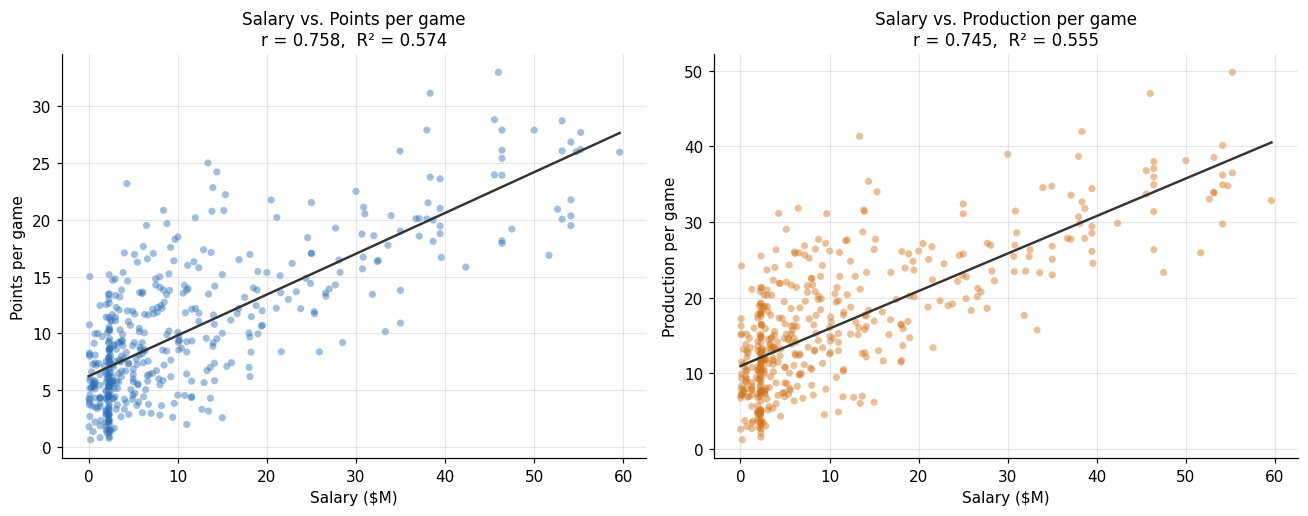

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (m, lab, c) in zip(axes, [("pointsPerGame", "Points per game", "#2c6fb5"),
                                  ("productionPerGame", "Production per game", "#d1731a")]):
    x = df["salary"] / 1e6
    ax.scatter(x, df[m], alpha=.45, s=22, color=c, edgecolor="none")
    fit = stats.linregress(df["salary"], df[m])
    xs = np.linspace(0, x.max(), 100); ax.plot(xs, fit.intercept + fit.slope * xs * 1e6, color="#333", lw=1.6)
    ax.set_xlabel("Salary ($M)"); ax.set_ylabel(lab)
    ax.set_title(f"Salary vs. {lab}\nr = {fit.rvalue:.3f},  R² = {fit.rvalue**2:.3f}", fontsize=11)
plt.tight_layout(); plt.savefig(FIG / "01-salary-vs-performance.png", dpi=150, bbox_inches="tight"); plt.show()

## 2. The minutes channel

Expensive players play more minutes, and per-game counting stats reward minutes. Compare per-game against per-36, and compute the partial correlation of salary and production holding minutes fixed.

In [4]:
df["prod36"] = df["productionPerGame"] / df["minutesPerGame"] * 36
df["pts36"] = df["pointsPerGame"] / df["minutesPerGame"] * 36

def partial_r(x, y, z):
    ex = x - np.polyval(np.polyfit(z, x, 1), z)
    ey = y - np.polyval(np.polyfit(z, y, 1), z)
    return stats.pearsonr(ex, ey)

pr, pp = partial_r(df["salary"].values, df["productionPerGame"].values, df["minutesPerGame"].values)
out = pd.DataFrame([
    ("salary vs minutes per game",           stats.pearsonr(df["salary"], df["minutesPerGame"])[0]),
    ("minutes per game vs production",       stats.pearsonr(df["minutesPerGame"], df["productionPerGame"])[0]),
    ("salary vs production (per game)",      stats.pearsonr(df["salary"], df["productionPerGame"])[0]),
    ("salary vs points (per 36)",            stats.pearsonr(df["salary"], df["pts36"])[0]),
    ("salary vs production (per 36)",        stats.pearsonr(df["salary"], df["prod36"])[0]),
    ("salary vs production | minutes (partial)", pr),
], columns=["relationship", "r"])
out["R2"] = out["r"] ** 2
out.round(3)

,relationship,r,R2
0,salary vs minutes per game,0.614,0.377
1,minutes per game vs production,0.901,0.812
2,salary vs production (per game),0.745,0.555
3,salary vs points (per 36),0.651,0.424
4,salary vs production (per 36),0.621,0.386
5,salary vs production | minutes (partial),0.560,0.314


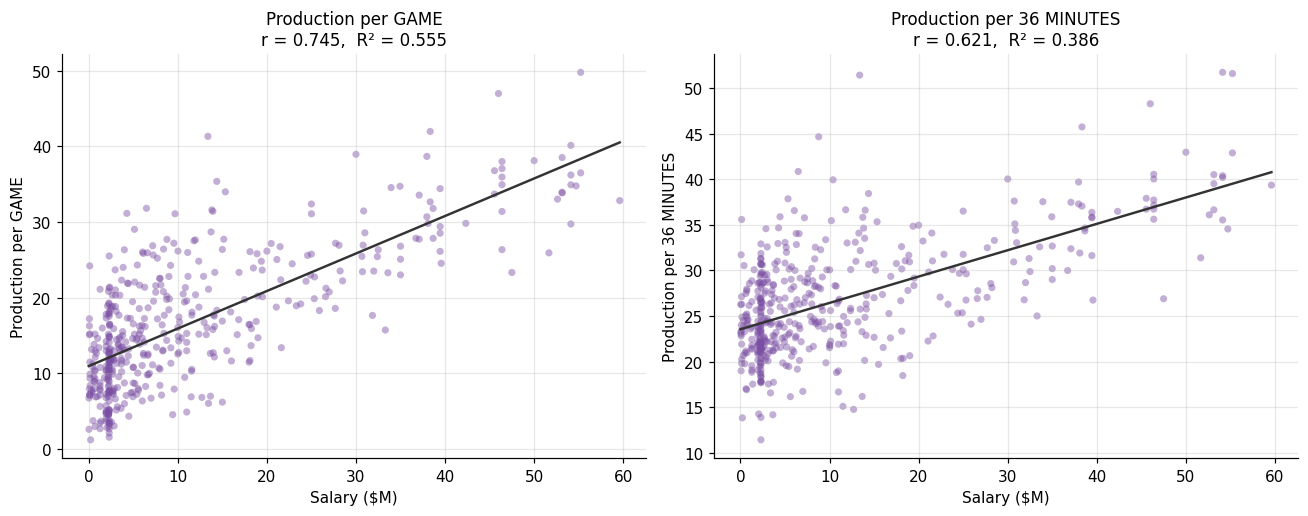

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (m, lab) in zip(axes, [("productionPerGame", "Production per GAME"), ("prod36", "Production per 36 MINUTES")]):
    x = df["salary"] / 1e6
    fit = stats.linregress(df["salary"], df[m])
    ax.scatter(x, df[m], alpha=.45, s=22, color="#7a4fa3", edgecolor="none")
    xs = np.linspace(0, x.max(), 100); ax.plot(xs, fit.intercept + fit.slope * xs * 1e6, color="#333", lw=1.6)
    ax.set_xlabel("Salary ($M)"); ax.set_ylabel(lab)
    ax.set_title(f"{lab}\nr = {fit.rvalue:.3f},  R² = {fit.rvalue**2:.3f}", fontsize=11)
plt.tight_layout(); plt.savefig(FIG / "02-minutes-effect.png", dpi=150, bbox_inches="tight"); plt.show()

## 3. Rookie scale vs. veteran max: test choice and the ratio problem

`ttest_ind` assumes equal variances by default. The two tiers' standard deviations differ by orders of magnitude, so Welch's t-test and Mann-Whitney U are the appropriate checks. Then: how much of production-per-dollar is just 1/salary?

In [6]:
lo, hi = df[df["salary"] < 5e6], df[df["salary"] > 30e6]
summary = pd.DataFrame({
    "n": [len(lo), len(hi)],
    "mean": [lo.prod_per_million.mean(), hi.prod_per_million.mean()],
    "median": [lo.prod_per_million.median(), hi.prod_per_million.median()],
    "sd": [lo.prod_per_million.std(), hi.prod_per_million.std()],
}, index=["< $5M", "> $30M"]).round(2)
display(summary)

tests = pd.DataFrame([
    ("Student t (equal_var=True, as in main notebook)", *stats.ttest_ind(lo.prod_per_million, hi.prod_per_million)),
    ("Welch t (equal_var=False)", *stats.ttest_ind(lo.prod_per_million, hi.prod_per_million, equal_var=False)),
    ("Mann-Whitney U", *stats.mannwhitneyu(lo.prod_per_million, hi.prod_per_million)),
], columns=["test", "statistic", "p"])
display(tests)

print(f"corr(prod_per_million, 1/salary)   r   = {stats.pearsonr(df.prod_per_million, 1/df.salary)[0]:.3f}")
print(f"spearman(prod_per_million, salary) rho = {stats.spearmanr(df.prod_per_million, df.salary)[0]:.3f}")
df.nlargest(5, "prod_per_million")[["playerName", "team", "salary", "productionPerGame", "prod_per_million"]].round(2)

,n,mean,median,sd
< $5M,212,14.69,4.84,37.18
> $30M,56,0.75,0.75,0.14


,test,statistic,p
0,"Student t (equal_var=True, as in main notebook)",2.800902,5.469997e-03
1,Welch t (equal_var=False),5.457084,1.350717e-07
2,Mann-Whitney U,11819.000000,4.045216e-30


corr(prod_per_million, 1/salary)   r   = 0.802
spearman(prod_per_million, salary) rho = -0.857


,playerName,team,salary,productionPerGame,prod_per_million
262,A.J. Lawson,TOR,26394.0,6.71,254.22
455,Bez Mbeng,UTA,73153.0,17.19,234.99
304,Tyler Burton,MEM,73153.0,16.25,222.14
369,Malachi Smith,BRK,73153.0,15.08,206.14
287,Kennedy Chandler,UTA,117730.0,24.18,205.39


## 4. Residuals: value relative to price point

Fit production on salary and rank players by how far they sit above or below the line. Unlike production-per-dollar, this doesn't mechanically favor the cheapest contracts.

In [7]:
fit = stats.linregress(df["salary"], df["productionPerGame"])
print(f"production per game = {fit.intercept:.2f} + {fit.slope*1e6:.3f} x salary($M)   R² = {fit.rvalue**2:.3f}")
df["expected"] = fit.intercept + fit.slope * df["salary"]
df["surplus"] = df["productionPerGame"] - df["expected"]
cols = ["playerName", "team", "salary", "productionPerGame", "expected", "surplus"]
print("Largest surplus"); display(df.nlargest(10, "surplus")[cols].round(1))
print("Largest deficit"); display(df.nsmallest(10, "surplus")[cols].round(1))

production per game = 10.94 + 0.496 x salary($M)   R² = 0.555
Largest surplus


,playerName,team,salary,productionPerGame,expected,surplus
327,Victor Wembanyama,SAS,13376880.0,41.3,17.6,23.7
338,Keyonte George,UTA,4278960.0,31.1,13.1,18.1
281,Jalen Duren,DET,6483144.0,31.8,14.2,17.6
187,Deni Avdija,POR,14375000.0,35.4,18.1,17.3
167,Kevin Porter Jr.,MIL,5134000.0,29.0,13.5,15.5
273,Paolo Banchero,ORL,15334769.0,34.0,18.5,15.4
330,Amen Thompson,HOU,9690600.0,31.1,15.7,15.3
418,Cooper Flagg,DAL,13825920.0,31.6,17.8,13.8
239,Austin Reaves,LAL,13937574.0,31.4,17.9,13.5
7,Russell Westbrook,SAC,2296274.0,25.5,12.1,13.4


Largest deficit


,playerName,team,salary,productionPerGame,expected,surplus
95,Jonathan Isaac,ORL,15000000.0,6.2,18.4,-12.2
30,Khris Middleton,DAL,33296296.0,15.7,27.4,-11.7
33,Kelly Olynyk,SAS,13445122.0,6.0,17.6,-11.6
112,Maxi Kleber,LAL,11000000.0,4.9,16.4,-11.5
42,Zach LaVine,SAC,47499660.0,23.3,34.5,-11.2
71,Pat Connaughton,CHO,9423869.0,4.5,15.6,-11.1
198,Josh Green,CHO,13666667.0,7.0,17.7,-10.8
18,Paul George,PHI,51666090.0,25.9,36.6,-10.7
17,Garrett Temple,TOR,2296274.0,1.5,12.1,-10.5
88,Dorian Finney-Smith,HOU,12700000.0,6.8,17.2,-10.4


In [8]:
vm = df[df["salary"] > 30e6]
print(f"Max tier (> $30M, n={len(vm)}): surplus ranges {vm.surplus.min():.1f} to {vm.surplus.max():.1f}")
display(pd.concat([vm.nlargest(5, "surplus"), vm.nsmallest(5, "surplus")])[cols].round(1))

Max tier (> $30M, n=56): surplus ranges -11.7 to 13.2


,playerName,team,salary,productionPerGame,expected,surplus
143,Luka Doncic,LAL,45999660.0,47.0,33.7,13.2
123,Shai Gilgeous-Alexander,OKC,38333050.0,42.0,29.9,12.0
57,Nikola Jokic,DEN,55224526.0,49.8,38.3,11.4
196,Tyrese Maxey,PHI,37958760.0,38.6,29.8,8.9
248,Alperen Sengun,HOU,33944954.0,34.5,27.8,6.8
30,Khris Middleton,DAL,33296296.0,15.7,27.4,-11.7
42,Zach LaVine,SAC,47499660.0,23.3,34.5,-11.2
18,Paul George,PHI,51666090.0,25.9,36.6,-10.7
175,Jordan Poole,NOP,31848215.0,17.6,26.7,-9.1
25,Jimmy Butler III,GSW,54126450.0,29.7,37.8,-8.1


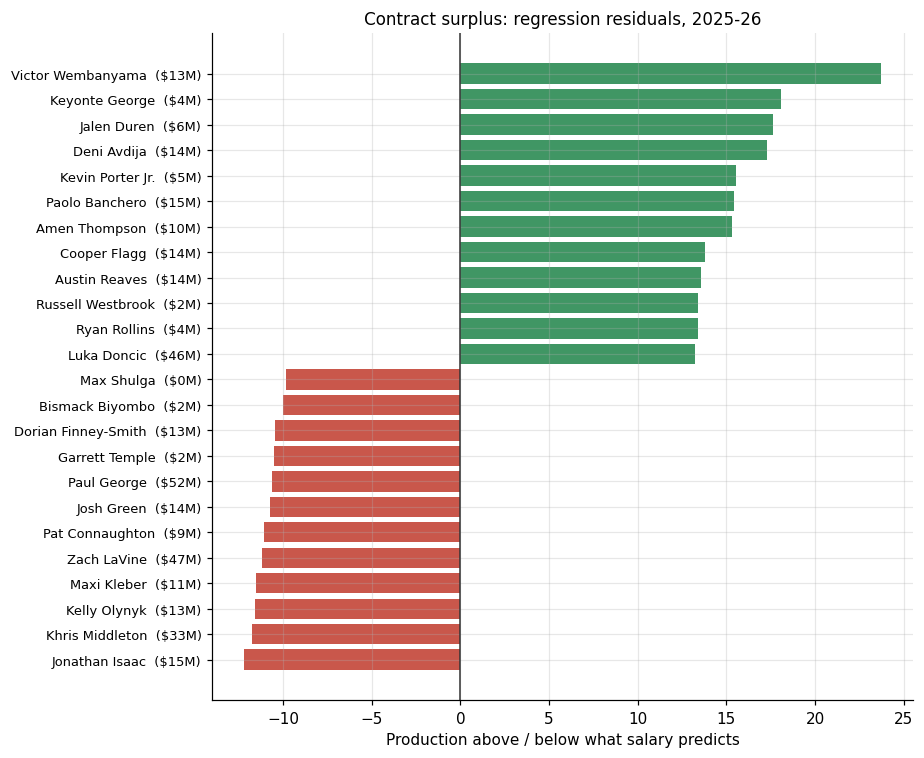

In [9]:
sel = pd.concat([df.nlargest(12, "surplus"), df.nsmallest(12, "surplus")]).sort_values("surplus")
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.barh(range(len(sel)), sel["surplus"], color=["#c0392b" if v < 0 else "#1e8449" for v in sel["surplus"]], alpha=.85)
ax.set_yticks(range(len(sel)))
ax.set_yticklabels([f"{n}  (${s/1e6:.0f}M)" for n, s in zip(sel.playerName, sel.salary)], fontsize=8.5)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("Production above / below what salary predicts")
ax.set_title("Contract surplus: regression residuals, 2025-26", fontsize=11)
plt.tight_layout(); plt.savefig(FIG / "03-contract-surplus.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Robustness checks

**Shooting penalty.** The production metric omits missed shots. Real EFF subtracts missed field goals and free throws.

In [10]:
g = df["gamesPlayed"]
df["eff"] = (df["productionPerGame"]
             - (df["fieldGoalsAttempted"] - df["fieldGoalsMade"]) / g
             - (df["freeThrowsAttempted"] - df["freeThrowsMade"]) / g)
for m in ["productionPerGame", "eff"]:
    r = stats.pearsonr(df["salary"], df[m])[0]
    print(f"salary vs {m:18s} r = {r:.3f}  R² = {r**2:.3f}   (mean {df[m].mean():.1f})")
df.assign(penalty=df.productionPerGame - df.eff).nlargest(5, "penalty")[["playerName", "productionPerGame", "eff", "penalty"]].round(1)

salary vs productionPerGame  r = 0.745  R² = 0.555   (mean 16.6)
salary vs eff                r = 0.721  R² = 0.520   (mean 11.9)


,playerName,productionPerGame,eff,penalty
143,Luka Doncic,47.0,33.0,13.9
83,Jaylen Brown,38.5,25.6,12.9
196,Tyrese Maxey,38.6,26.6,12.0
184,Anthony Edwards,36.8,25.0,11.8
119,Jalen Brunson,34.7,23.2,11.5


**Availability.** Is salary related to games played? (Note: the 10-game filter is applied upstream, so players who missed nearly the whole season are already excluded.)

In [11]:
r = stats.pearsonr(df["salary"], df["gamesPlayed"])[0]
print(f"salary vs games played r = {r:.3f}")
print(f"median games played: {df.gamesPlayed.median():.0f};  share with 70+: {(df.gamesPlayed >= 70).mean():.0%}")

salary vs games played r = 0.106
median games played: 58;  share with 70+: 25%


**Name-matching losses.** 52 of 508 players in the performance file didn't match a salary. Most are two-way players with no standard salary, but four are name mismatches. `scripts/build_dataset.py --fix-aliases` recovers them; here's whether it changes anything.

In [12]:
perf = pd.read_csv("data/performance_2025_26_cleaned.csv")
lost = perf[~perf["personId"].isin(df["personId"])]
print(f"unmatched: {len(lost)};  mean production {lost.productionPerGame.mean():.1f} vs {df.productionPerGame.mean():.1f} matched")

alias_path = Path("data/nba_salary_performance_2025_26_aliased.csv")
if alias_path.exists():
    a = pd.read_csv(alias_path)
    recovered = a[~a["personId"].isin(df["personId"])][["playerName", "team", "salary", "gamesPlayed", "productionPerGame"]]
    display(recovered)
    for m in ["pointsPerGame", "productionPerGame"]:
        r0 = stats.pearsonr(df.salary, df[m])[0]; r1 = stats.pearsonr(a.salary, a[m])[0]
        print(f"{m}: r = {r0:.3f} (n={len(df)})  ->  {r1:.3f} (n={len(a)})")
else:
    print("Run `python scripts/build_dataset.py --fix-aliases` to generate the aliased file.")

unmatched: 52;  mean production 9.2 vs 16.6 matched


,playerName,team,salary,gamesPlayed,productionPerGame
335,GG Jackson,MEM,2221677.0,55,18.02
369,Ronald Holland II,DET,8657280.0,78,13.77
431,Egor Demin,BRK,6889200.0,53,15.97
437,Hugo Gonzalez,BOS,2783880.0,74,8.11


pointsPerGame: r = 0.758 (n=456)  ->  0.757 (n=460)
productionPerGame: r = 0.745 (n=456)  ->  0.745 (n=460)
